In [13]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

In [14]:
import mne

# load one file
raw = mne.io.read_raw_edf('../data/S001R04.edf', preload=True)

# print basic info
print(raw.info)

Extracting EDF parameters from ../data/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


c:\Users\Mush\eeg_classification\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


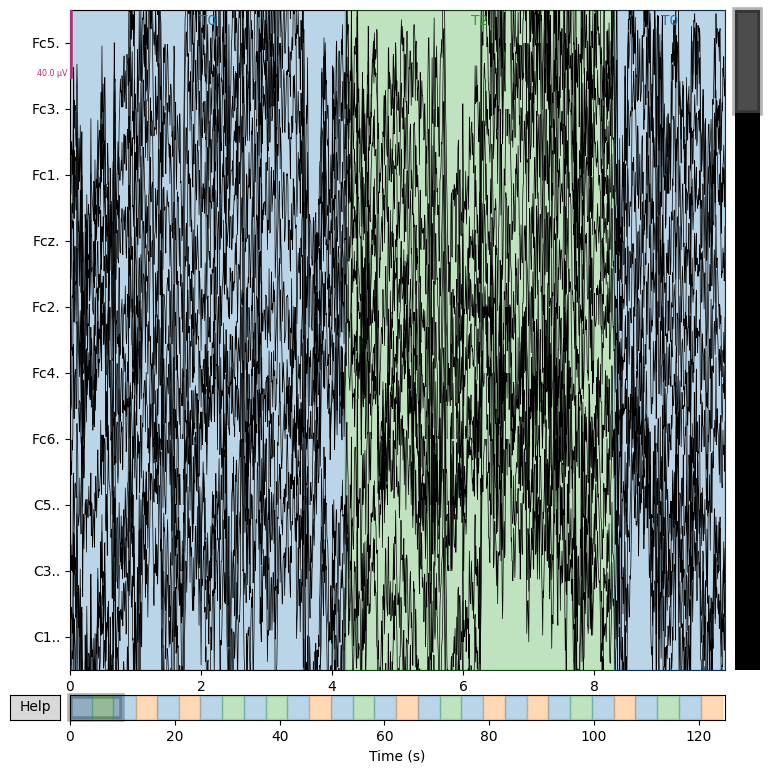

In [15]:
raw.plot(duration=10, n_channels=10)

In [16]:
print(raw.annotations)

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


In [17]:
for ann in raw.annotations:
    print(f"{ann['description']}  onset={ann['onset']:.1f}s  duration={ann['duration']:.1f}s")

T0  onset=0.0s  duration=4.2s
T2  onset=4.2s  duration=4.1s
T0  onset=8.3s  duration=4.2s
T1  onset=12.5s  duration=4.1s
T0  onset=16.6s  duration=4.2s
T1  onset=20.8s  duration=4.1s
T0  onset=24.9s  duration=4.2s
T2  onset=29.1s  duration=4.1s
T0  onset=33.2s  duration=4.2s
T2  onset=37.4s  duration=4.1s
T0  onset=41.5s  duration=4.2s
T1  onset=45.7s  duration=4.1s
T0  onset=49.8s  duration=4.2s
T2  onset=54.0s  duration=4.1s
T0  onset=58.1s  duration=4.2s
T1  onset=62.3s  duration=4.1s
T0  onset=66.4s  duration=4.2s
T2  onset=70.6s  duration=4.1s
T0  onset=74.7s  duration=4.2s
T1  onset=78.9s  duration=4.1s
T0  onset=83.0s  duration=4.2s
T1  onset=87.2s  duration=4.1s
T0  onset=91.3s  duration=4.2s
T2  onset=95.5s  duration=4.1s
T0  onset=99.6s  duration=4.2s
T1  onset=103.8s  duration=4.1s
T0  onset=107.9s  duration=4.2s
T2  onset=112.1s  duration=4.1s
T0  onset=116.2s  duration=4.2s
T1  onset=120.4s  duration=4.1s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



c:\Users\Mush\eeg_classification\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\Mush\eeg_classification\venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


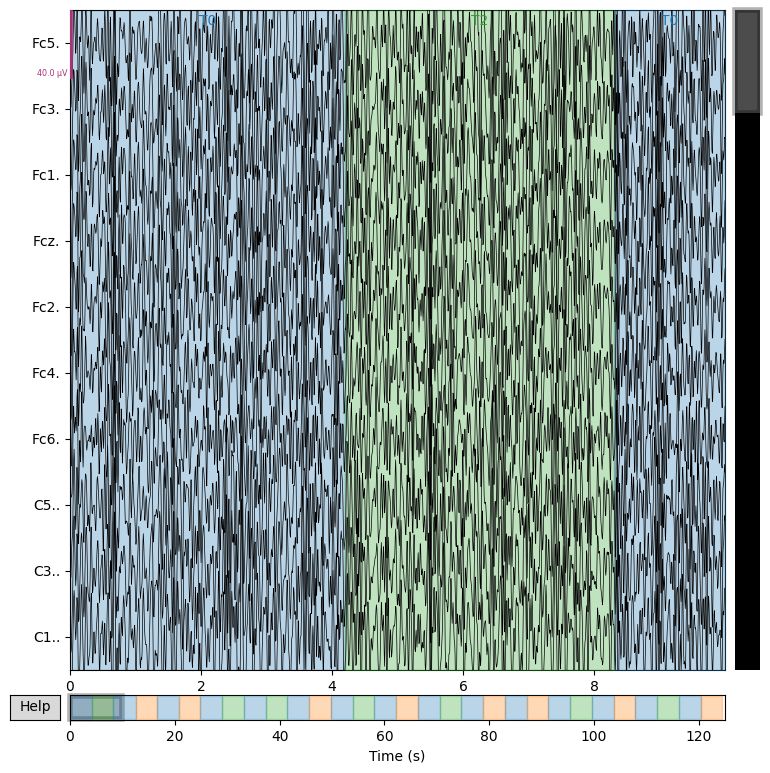

In [ ]:
raw_filtered = raw.copy().filter(l_freq=8, h_freq=30)
raw.plot(duration=10, n_channels=10, title='Raw')
raw_filtered.plot(duration=10, n_channels=10, title='Filtered')

In [28]:
fig = raw.compute_psd().plot(picks='eeg', show=False)
plt.savefig('../results/psd_raw.png')
plt.close()

fig = raw_filtered.compute_psd().plot(picks='eeg', show=False)
plt.savefig('../results/psd_filtered.png')
plt.close()

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\Mush\AppData\Local\Temp\ipykernel_136472\2725744702.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd().plot(picks='eeg', show=False)


Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\Mush\AppData\Local\Temp\ipykernel_136472\2725744702.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw_filtered.compute_psd().plot(picks='eeg', show=False)


In [29]:
from mne.epochs import make_metadata
import numpy as np

# define events from annotations
events, event_id = mne.events_from_annotations(raw_filtered)

print(event_id)
print(events[:10])

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [30]:
# extract epochs for T1 (left) and T2 (right) only
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id={'T1': 2, 'T2': 3},
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print(epochs)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.7 MiB, data loaded,
 'T1': 8
 'T2': 7>


In [31]:
print(epochs.get_data().shape)

(15, 64, 641)


In [32]:
X = epochs.get_data()          # shape (15, 64, 641)
y = epochs.events[:, 2] - 2   # converts T1=2,T2=3 → 0,1

print(X.shape)
print(y)

(15, 64, 641)
[1 0 0 1 1 0 1 0 1 0 0 1 0 1 0]
